In [54]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.linalg import expm, logm
from scipy.sparse import diags, eye, kron
from scipy.sparse.linalg import splu, spsolve

## Funzioni generali DMD

In [55]:
def choose_rank_from_energy(singular_values, energy=0.9999, max_rank=None):

    s = np.asarray(singular_values)

    if len(s) == 0:
        raise ValueError("La lista dei valori singolari è vuota.")

    # Rango numerico: valori singolari troppo piccoli non devono essere invertiti.
    tol = np.finfo(float).eps * max(1, len(s)) * s[0]
    numerical_rank = int(np.sum(s > tol))

    if numerical_rank == 0:
        raise ValueError("La matrice degli snapshot ha rango numerico nullo.")

    # Energia cumulata associata ai valori singolari non nulli.
    s_eff = s[:numerical_rank]
    cumulative_energy = np.cumsum(s_eff**2) / np.sum(s_eff**2)

    # Primo indice in cui viene raggiunta l'energia richiesta.
    r = int(np.searchsorted(cumulative_energy, energy) + 1)

    if max_rank is not None:
        r = min(r, int(max_rank))

    return max(1, r)


def dmd_fit(snapshots, dt, rank=None, energy=0.9999, max_rank=None):

    X = np.asarray(snapshots)

    if X.ndim != 2:
        raise ValueError("snapshots deve essere una matrice 2D (d x numero_snapshot).")
    if X.shape[1] < 2:
        raise ValueError("Servono almeno due snapshot.")
    if dt <= 0:
        raise ValueError("dt deve essere positivo.")

    # Costruzione delle due matrici della DMD:
    #    X  = [y_0, ..., y_{m-1}]
    #    X' = [y_1, ..., y_m]
    Y = X[:, :-1]  #primo -> penultimo snapshot
    Yp = X[:, 1:]  #secondo -> ultimo

    # SVD economica di X.
    U_full, s_full, Vh_full = np.linalg.svd(Y, full_matrices=False)

    # Rango numerico disponibile: non invertiamo valori singolari praticamente nulli.
    tol = np.finfo(float).eps * max(Y.shape) * s_full[0]
    numerical_rank = int(np.sum(s_full > tol))

    if rank is None: r = choose_rank_from_energy(s_full, energy=energy, max_rank=max_rank)
    else: r = min(int(rank), numerical_rank)

    if r < 1: raise ValueError("Il rango DMD selezionato deve essere almeno 1.")

    # Troncamento SVD ai primi r modi.
    U = U_full[:, :r]
    s = s_full[:r]
    V = Vh_full.conj().T[:, :r]

    # Sigma^{-1}; essendo Sigma diagonale basta invertire i valori singolari.
    Sigma_inv = np.diag(1.0 / s)

    # Operatore DMD ridotto:
    # A_tilde = U^T X' V Sigma^{-1}
    A_tilde = U.conj().T @ Yp @ V @ Sigma_inv

    #Autovalori/autovettori dell'operatore ridotto.
    eigvals, W = np.linalg.eig(A_tilde)

    # Modi Exact DMD nello spazio originale:
    # Phi = X' V Sigma^{-1} W
    Phi = Yp @ V @ Sigma_inv @ W

    # Frequenze continue:
    #    omega_j = log(lambda_j) / dt
    #    tipo complex perché log di autovalori negativi/complessi è complesso.
    omega = np.log(eigvals.astype(complex)) / dt

    # Coefficienti della condizione iniziale nella base dei modi DMD:
    #    b = Phi^dagger y_0
    #    np.linalg.lstsq calcola la soluzione ai minimi quadrati senza formare esplicitamente la pseudoinversa.

    b = np.linalg.lstsq(Phi, X[:, 0], rcond=None)[0]

    return {
        "X": X,
        "Yp": Yp,
        "U": U,
        "singular_values": s,
        "all_singular_values": s_full,
        "V": V,
        "A_tilde": A_tilde,
        "eigvals": eigvals,
        "W": W,
        "Phi": Phi,
        "omega": omega,
        "b": b,
        "rank": r,
        "dt": dt,
    }


def dmd_reconstruct(model, times, t0=None, return_real=True):

    t = np.asarray(times)

    if t0 is None:
        t0 = t[0]

    Phi = model["Phi"]
    omega = model["omega"]
    b = model["b"]

    # Ogni riga contiene l'evoluzione temporale di un coefficiente modale.
    time_dynamics = b[:, None] * np.exp(omega[:, None] * (t[None, :] - t0))

    Y_dmd = Phi @ time_dynamics

    if return_real:
        # Per dataset reali prendiamo la parte reale della somma dei modi coniugati.
        Y_dmd = Y_dmd.real

    return Y_dmd


def relative_snapshot_error(Y_true, Y_approx, floor=1e-14):
    """Errore relativo 2-norma, snapshot per snapshot."""
    numerator = np.linalg.norm(Y_true - Y_approx, axis=0)
    denominator = np.maximum(np.linalg.norm(Y_true, axis=0), floor)
    return numerator / denominator


def relative_frobenius_error(Y_true, Y_approx):
    """Errore relativo globale in norma di Frobenius."""
    return np.linalg.norm(Y_true - Y_approx, "fro") / np.linalg.norm(Y_true, "fro")


def plot_error_curve(t, err, title, ylabel="Errore relativo"):
    """Grafico semilogaritmico dell'errore."""
    plt.figure(figsize=(9, 4.5))
    plt.semilogy(t, np.maximum(err, 1e-16))
    plt.xlabel("t")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True)
    plt.show()

# Esercizio 1

In [56]:
# Parametri del problema.
omega0 = 2.0
A_harm = np.array([[0.0, 1.0],
                   [-omega0**2, 0.0]])
y0_harm = np.array([1.0, 0.0])

# Scelta numerica: la scheda non fissa T e Delta t per questo esercizio.
# Usiamo T=10 e Delta t=0.05, sufficientemente piccolo per risolvere bene l'oscillazione.
T_harm = 10.0
dt_harm = 0.05
t_harm = np.arange(0.0, T_harm + 0.5*dt_harm, dt_harm)

# Soluzione esatta e quindi dataset degli snapshot.
x_exact = np.cos(omega0 * t_harm)
v_exact = -omega0 * np.sin(omega0 * t_harm)
Y_harm = np.vstack([x_exact, v_exact])

print("Numero snapshot:", Y_harm.shape[1])
print("Dimensione di ogni snapshot:", Y_harm.shape[0])

Numero snapshot: 201
Dimensione di ogni snapshot: 2


### a)-c) 

In [57]:
model_harm = dmd_fit(Y_harm, dt=dt_harm, rank=2)

X_harm = model_harm["X"]
Yp_harm = model_harm["Yp"]
Atilde_harm = model_harm["A_tilde"]

print("Shape X :", X_harm.shape)
print("Shape X':", Yp_harm.shape)
print("\nValori singolari di X:")
print(model_harm["singular_values"])
print("\nOperatore DMD ridotto A_tilde:")
print(Atilde_harm)

Shape X : (2, 201)
Shape X': (2, 200)

Valori singolari di X:
[19.77687358 10.10224526]

Operatore DMD ridotto A_tilde:
[[ 0.99911448 -0.19955393]
 [ 0.05002961  0.99089385]]


### d) 

In [58]:
# Autovalori teorici continui di A.
eig_cont_theory = np.linalg.eigvals(A_harm).astype(complex)

# Autovalori teorici del propagatore discreto exp(A*dt).
eig_disc_theory = np.exp(eig_cont_theory * dt_harm)

# Autovalori ottenuti dalla DMD.
eig_disc_dmd = model_harm["eigvals"]
eig_cont_dmd = model_harm["omega"]

# Ordiniamo per parte immaginaria solo per presentare il confronto in modo leggibile.
def sort_by_imag(z):
    z = np.asarray(z)
    return z[np.argsort(z.imag)]

comparison_eigs = pd.DataFrame({
    "continuo teorico": sort_by_imag(eig_cont_theory),
    "continuo da DMD": sort_by_imag(eig_cont_dmd),
    "discreto teorico": sort_by_imag(eig_disc_theory),
    "discreto DMD": sort_by_imag(eig_disc_dmd),
})

display(comparison_eigs)

,continuo teorico,continuo da DMD,discreto teorico,discreto DMD
0,0.0-2.0j,-0.0-2.0j,0.995004-0.099833j,0.995004-0.099833j
1,0.0+2.0j,-0.0+2.0j,0.995004+0.099833j,0.995004+0.099833j


In [59]:
U_harm = model_harm["U"]

# Propagatore discreto esatto del sistema continuo.
A_disc_exact = expm(A_harm * dt_harm)

# Lo portiamo nella stessa base ridotta U usata dalla DMD.
A_disc_exact_red = U_harm.T @ A_disc_exact @ U_harm

# Generatore continuo teorico nella stessa base ridotta.
A_cont_exact_red = U_harm.T @ A_harm @ U_harm

# Generatore continuo ricavato dall'operatore DMD discreto.
Atilde_cont = logm(Atilde_harm) / dt_harm
Atilde_cont = np.real_if_close(Atilde_cont, tol=1000)

print("Confronto DISCRETO")
print("||A_tilde - U^T exp(A dt) U||_F =",
      np.linalg.norm(Atilde_harm - A_disc_exact_red, "fro"))

print("\nConfronto CONTINUO")
print("||log(A_tilde)/dt - U^T A U||_F =",
      np.linalg.norm(Atilde_cont - A_cont_exact_red, "fro"))

print("\nU^T A U =")
print(A_cont_exact_red)
print("\nlog(A_tilde)/dt =")
print(Atilde_cont)

Confronto DISCRETO
||A_tilde - U^T exp(A dt) U||_F = 3.377324398933778e-16

Confronto CONTINUO
||log(A_tilde)/dt - U^T A U||_F = 5.189773124739329e-15

U^T A U =
[[ 0.08234355 -3.99773814]
 [ 1.00226186 -0.08234355]]

log(A_tilde)/dt =
[[ 0.08234355 -3.99773814]
 [ 1.00226186 -0.08234355]]


### e)

In [60]:
Y_harm_dmd = dmd_reconstruct(model_harm, t_harm)
err_harm_dmd = relative_snapshot_error(Y_harm, Y_harm_dmd)

print("Errore relativo globale DMD (Frobenius):",
      relative_frobenius_error(Y_harm, Y_harm_dmd))
print("Errore relativo massimo sui singoli snapshot:", err_harm_dmd.max())

Errore relativo globale DMD (Frobenius): 6.523035600243214e-15
Errore relativo massimo sui singoli snapshot: 1.3576379908700679e-14


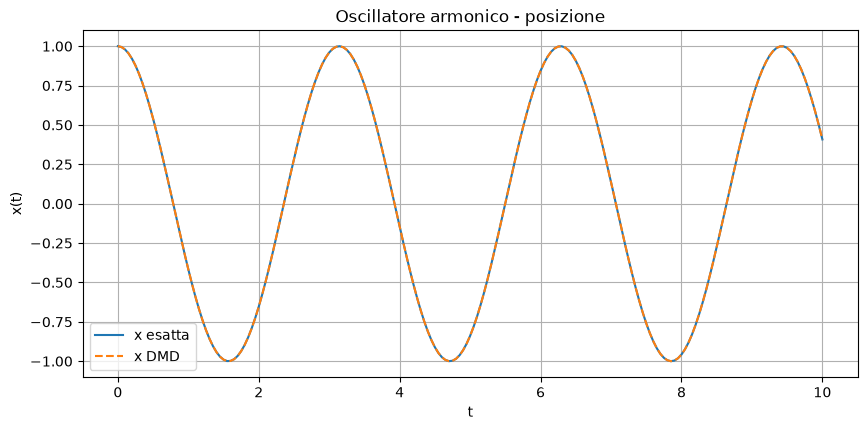

In [61]:
plt.figure(figsize=(10, 4.5))
plt.plot(t_harm, Y_harm[0], label="x esatta")
plt.plot(t_harm, Y_harm_dmd[0], "--", label="x DMD")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.title("Oscillatore armonico - posizione")
plt.grid(True)
plt.legend()
plt.show()

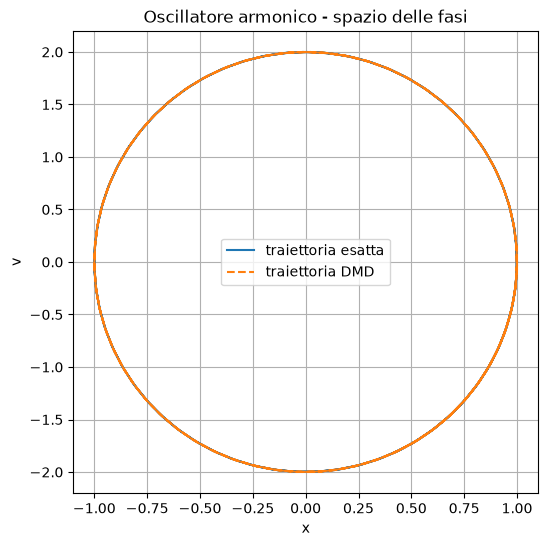

In [62]:
plt.figure(figsize=(6, 6))
plt.plot(Y_harm[0], Y_harm[1], label="traiettoria esatta")
plt.plot(Y_harm_dmd[0], Y_harm_dmd[1], "--", label="traiettoria DMD")
plt.xlabel("x")
plt.ylabel("v")
plt.title("Oscillatore armonico - spazio delle fasi")
plt.grid(True)
plt.legend()
plt.show()

### f)

In [63]:
# Stato iniziale nelle coordinate ridotte U.
z0_harm = U_harm.T @ y0_harm

# 1) ODE con A_tilde usata letteralmente come generatore continuo.
sol_raw = solve_ivp(
    lambda t, z: Atilde_harm @ z,
    (t_harm[0], t_harm[-1]),
    z0_harm,
    t_eval=t_harm,
    rtol=1e-10,
    atol=1e-12,
)
Y_harm_ode_raw = (U_harm @ sol_raw.y).real

# 2) ODE con il generatore continuo corretto log(A_tilde)/dt.
Atilde_cont_real = np.asarray(Atilde_cont).real
sol_cont = solve_ivp(
    lambda t, z: Atilde_cont_real @ z,
    (t_harm[0], t_harm[-1]),
    z0_harm,
    t_eval=t_harm,
    rtol=1e-10,
    atol=1e-12,
)
Y_harm_ode_cont = U_harm @ sol_cont.y

err_raw = relative_snapshot_error(Y_harm, Y_harm_ode_raw)
err_cont = relative_snapshot_error(Y_harm, Y_harm_ode_cont)

print("Errore Frobenius - modi DMD:", relative_frobenius_error(Y_harm, Y_harm_dmd))
print("Errore Frobenius - ODE con A_tilde usata direttamente:",
      relative_frobenius_error(Y_harm, Y_harm_ode_raw))
print("Errore Frobenius - ODE con log(A_tilde)/dt:",
      relative_frobenius_error(Y_harm, Y_harm_ode_cont))

Errore Frobenius - modi DMD: 6.523035600243214e-15
Errore Frobenius - ODE con A_tilde usata direttamente: 5277.865327997508
Errore Frobenius - ODE con log(A_tilde)/dt: 1.3764463239324705e-10


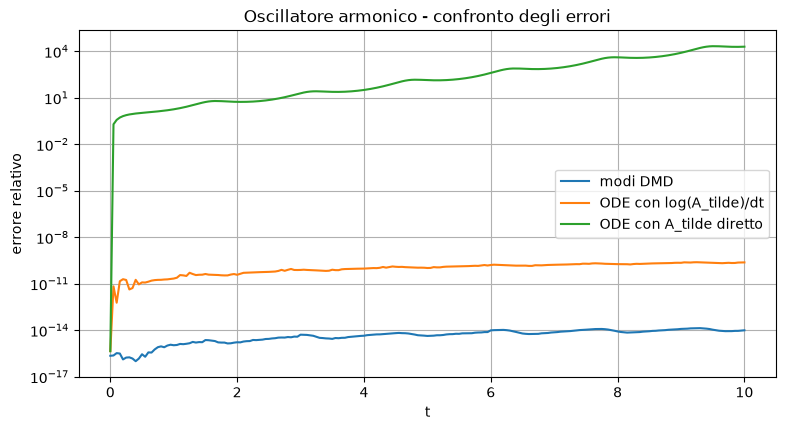

In [64]:
plt.figure(figsize=(9, 4.5))
plt.semilogy(t_harm, np.maximum(err_harm_dmd, 1e-16), label="modi DMD")
plt.semilogy(t_harm, np.maximum(err_cont, 1e-16), label="ODE con log(A_tilde)/dt")
plt.semilogy(t_harm, np.maximum(err_raw, 1e-16), label="ODE con A_tilde diretto")
plt.xlabel("t")
plt.ylabel("errore relativo")
plt.title("Oscillatore armonico - confronto degli errori")
plt.grid(True)
plt.legend()
plt.show()

# Esercizio 2 

In [65]:
def van_der_pol_rhs(t, y):
    y1, y2 = y
    return np.array([
        y2,
        (1.0 - y1**2) * y2 - y1,
    ])

T_vdp = 10.0
dt_vdp = 0.01
t_vdp = np.arange(0.0, T_vdp + 0.5*dt_vdp, dt_vdp)

sol_vdp = solve_ivp(
    van_der_pol_rhs,
    (0.0, T_vdp),
    np.array([2.0, 2.0]),
    t_eval=t_vdp,
    rtol=1e-10,
    atol=1e-12,
)

Y_vdp = sol_vdp.y
print("Shape dataset Van der Pol:", Y_vdp.shape)

Shape dataset Van der Pol: (2, 1001)


In [66]:
# Lo stato ha dimensione 2, quindi usiamo rango 2.
model_vdp = dmd_fit(Y_vdp, dt=dt_vdp, rank=2)
Y_vdp_dmd = dmd_reconstruct(model_vdp, t_vdp)
err_vdp = relative_snapshot_error(Y_vdp, Y_vdp_dmd)

print("A_tilde Van der Pol:")
print(model_vdp["A_tilde"])
print("\nAutovalori continui DMD omega_j:")
print(model_vdp["omega"])
print("\nErrore Frobenius relativo:", relative_frobenius_error(Y_vdp, Y_vdp_dmd))

A_tilde Van der Pol:
[[ 0.99964716 -0.00991241]
 [ 0.00912844  1.00020163]]

Autovalori continui DMD omega_j:
[-0.00303969+0.95087439j -0.00303969-0.95087439j]

Errore Frobenius relativo: 0.6644127592626418


In [67]:
J0_vdp = np.array([[0.0, 1.0],
                   [-1.0, 1.0]])

print("Autovalori del Jacobiano locale J(0,0):")
print(np.linalg.eigvals(J0_vdp))
print("\nAutovalori continui DMD globali:")
print(model_vdp["omega"])

Autovalori del Jacobiano locale J(0,0):
[0.5+0.8660254j 0.5-0.8660254j]

Autovalori continui DMD globali:
[-0.00303969+0.95087439j -0.00303969-0.95087439j]


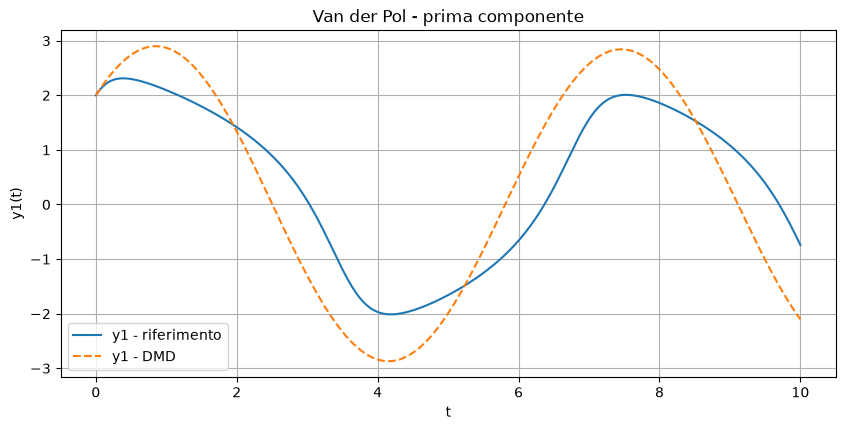

In [68]:
plt.figure(figsize=(10, 4.5))
plt.plot(t_vdp, Y_vdp[0], label="y1 - riferimento")
plt.plot(t_vdp, Y_vdp_dmd[0], "--", label="y1 - DMD")
plt.xlabel("t")
plt.ylabel("y1(t)")
plt.title("Van der Pol - prima componente")
plt.grid(True)
plt.legend()
plt.show()

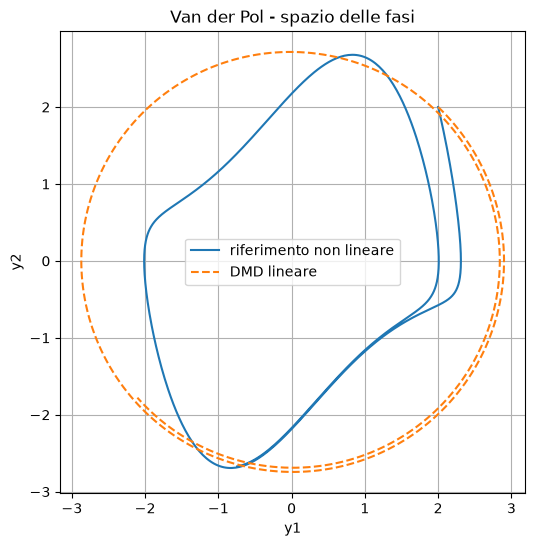

In [69]:
plt.figure(figsize=(6, 6))
plt.plot(Y_vdp[0], Y_vdp[1], label="riferimento non lineare")
plt.plot(Y_vdp_dmd[0], Y_vdp_dmd[1], "--", label="DMD lineare")
plt.xlabel("y1")
plt.ylabel("y2")
plt.title("Van der Pol - spazio delle fasi")
plt.grid(True)
plt.legend()
plt.show()

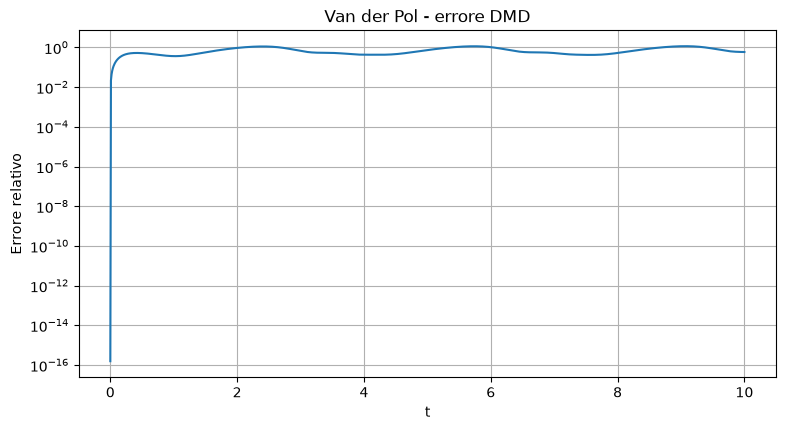

In [70]:
plot_error_curve(t_vdp, err_vdp, "Van der Pol - errore DMD")

### Interpretazione

L'errore è molto più grande che nell'oscillatore armonico. Questo è un risultato atteso:

- l'oscillatore armonico è esattamente lineare;
- Van der Pol contiene un termine cubico nello stato;
- una DMD standard costruisce un solo modello lineare globale.

DMD riesce a individuare una frequenza oscillatoria media, ma non riproduce perfettamente la regolazione non lineare dell'ampiezza e della forma del ciclo limite.

# Esercizio 3 

In [71]:
def laplacian_1d(n, h):
    # Laplaciano 1D sui soli nodi interni, con Dirichlet omogenee ai bordi.
    # Matrice tridiagonale:
    #     1/h^2 * [ 1  -2  1 ]
    # applicata a ogni nodo interno.
    main = -2.0 * np.ones(n)
    off = np.ones(n - 1)
    return diags([off, main, off], offsets=[-1, 0, 1], format="csc") / h**2


def laplacian_2d(n, h):
    #Laplaciano 2D su una griglia interna n x n.
    #Se L1 è il Laplaciano 1D e I l'identità:
    #    L2 = I ⊗ L1 + L1 ⊗ I
    #Questa formula costruisce automaticamente lo stencil a cinque punti. (Vedi scheda 3)

    L1 = laplacian_1d(n, h)
    I = eye(n, format="csc")

    # Primo termine: derivata seconda in una direzione.
    # Secondo termine: derivata seconda nell'altra direzione.
    return kron(I, L1, format="csc") + kron(L1, I, format="csc")


def vector_to_full_grid(u, x):
    N = len(x)
    n = N - 2
    full = np.zeros((N, N))
    full[1:-1, 1:-1] = np.asarray(u).reshape(n, n)
    return full


def plot_field_2d(u, x, title):
    #Visualizza un singolo campo 2D.
    field = vector_to_full_grid(u, x)
    plt.figure(figsize=(6.2, 5.2))
    plt.imshow(
        field.T,
        origin="lower",
        extent=[x[0], x[-1], x[0], x[-1]],
        aspect="equal",
    )
    plt.colorbar(label="y")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.show()

### Equazione del calore 2D

In [72]:
def heat_2d_backward_euler(alpha, y0_fun, T=1.0, N=31, dt=0.01, snapshot_stride=1):
    x = np.linspace(0.0, 1.0, N)
    h = x[1] - x[0]
    xi = x[1:-1]
    X1, X2 = np.meshgrid(xi, xi, indexing="ij")

    n = N - 2
    L = laplacian_2d(n, h)
    I = eye(n*n, format="csc")

    # Backward Euler:
    # (I - dt * alpha * L) y_{k+1} = y_k
    M = I - dt * alpha * L
    solver = splu(M).solve

    u = np.asarray(y0_fun(X1, X2), dtype=float).ravel()

    nsteps = int(round(T / dt))
    snapshots = [u.copy()]
    times = [0.0]

    for k in range(1, nsteps + 1):
        u = solver(u)

        if k % snapshot_stride == 0:
            snapshots.append(u.copy())
            times.append(k * dt)

    return x, np.asarray(times), np.column_stack(snapshots)

In [73]:
# parametro alpha = 0.01 e funzione iniziale y0 = sin(2 pi x1) sin(2 pi x2)

def heat_y0_sine(X1, X2):
    return np.sin(2*np.pi*X1) * np.sin(2*np.pi*X2)

x_heat1, t_heat1, Y_heat1 = heat_2d_backward_euler(
    alpha=0.01,
    y0_fun=heat_y0_sine,
    T=1.0,
    N=31,
    dt=0.01,
)

model_heat1 = dmd_fit(Y_heat1, dt=t_heat1[1]-t_heat1[0], energy=0.99999, max_rank=30)
Y_heat1_dmd = dmd_reconstruct(model_heat1, t_heat1)
err_heat1 = relative_snapshot_error(Y_heat1, Y_heat1_dmd)

print("Rango DMD selezionato:", model_heat1["rank"])
print("Errore Frobenius relativo:", relative_frobenius_error(Y_heat1, Y_heat1_dmd))

Rango DMD selezionato: 1
Errore Frobenius relativo: 9.739628421808344e-15


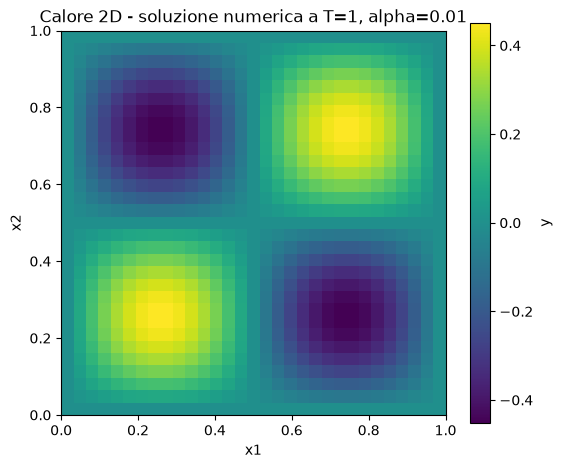

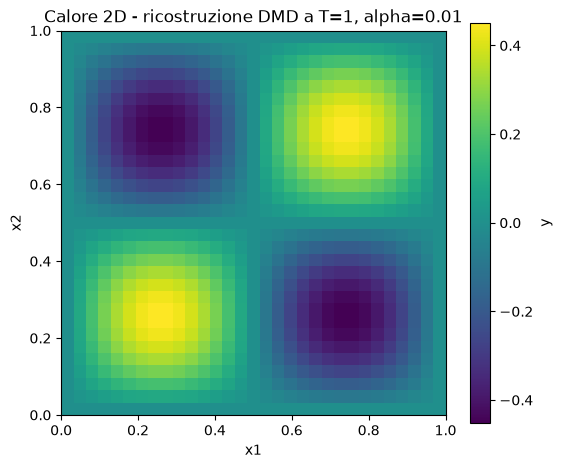

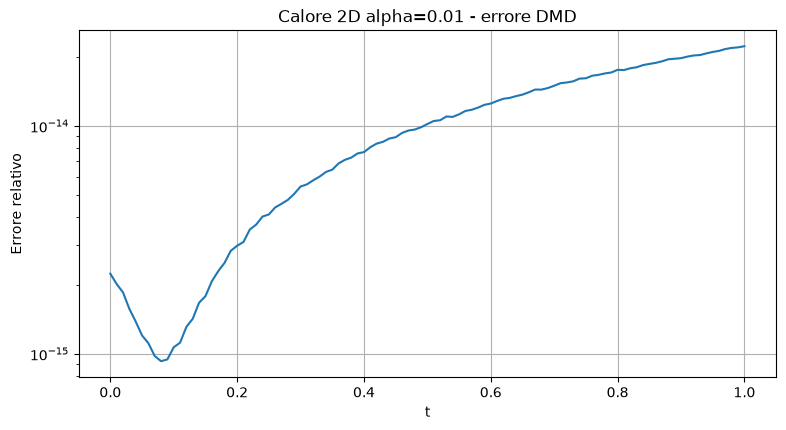

In [74]:
plot_field_2d(Y_heat1[:, -1], x_heat1, "Calore 2D - soluzione numerica a T=1, alpha=0.01")
plot_field_2d(Y_heat1_dmd[:, -1], x_heat1, "Calore 2D - ricostruzione DMD a T=1, alpha=0.01")
plot_error_curve(t_heat1, err_heat1, "Calore 2D alpha=0.01 - errore DMD")

In [75]:
# parametro alpha = 0.05 e funzione iniziale y0 = blocco rettangolare centrato


def heat_y0_block(X1, X2):
    return ((X1 > 0.25) & (X1 < 0.75) &
            (X2 > 0.25) & (X2 < 0.75)).astype(float)

x_heat2, t_heat2, Y_heat2 = heat_2d_backward_euler(
    alpha=0.05,
    y0_fun=heat_y0_block,
    T=1.0,
    N=31,
    dt=0.01,
)

model_heat2 = dmd_fit(Y_heat2, dt=t_heat2[1]-t_heat2[0], energy=0.99999, max_rank=30)
Y_heat2_dmd = dmd_reconstruct(model_heat2, t_heat2)
err_heat2 = relative_snapshot_error(Y_heat2, Y_heat2_dmd)

print("Rango DMD selezionato:", model_heat2["rank"])
print("Errore Frobenius relativo:", relative_frobenius_error(Y_heat2, Y_heat2_dmd))

Rango DMD selezionato: 5
Errore Frobenius relativo: 0.004734028273263245


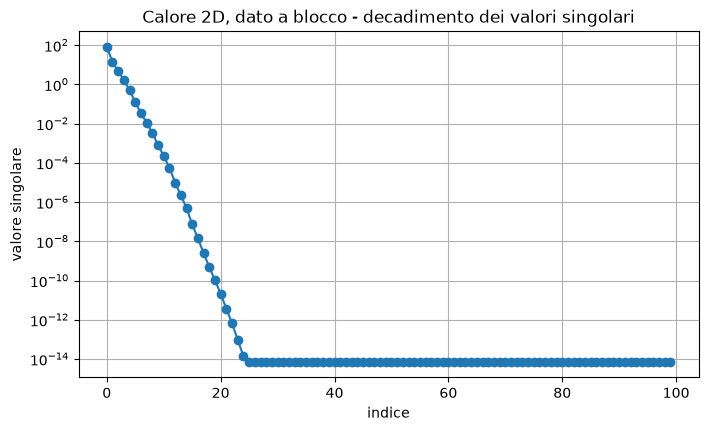

In [76]:
plt.figure(figsize=(8, 4.5))
plt.semilogy(model_heat2["all_singular_values"], "o-")
plt.xlabel("indice")
plt.ylabel("valore singolare")
plt.title("Calore 2D, dato a blocco - decadimento dei valori singolari")
plt.grid(True)
plt.show()

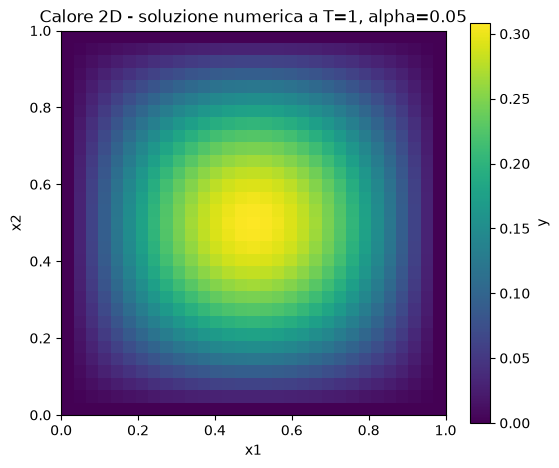

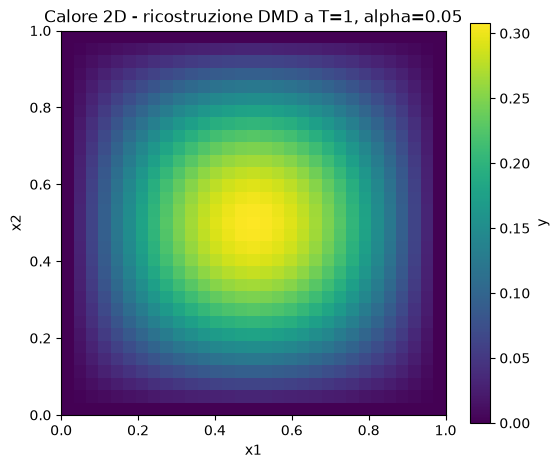

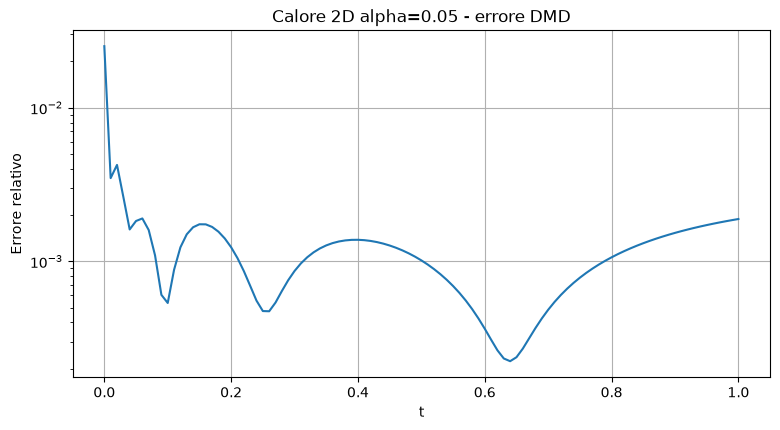

In [77]:
plot_field_2d(Y_heat2[:, -1], x_heat2, "Calore 2D - soluzione numerica a T=1, alpha=0.05")
plot_field_2d(Y_heat2_dmd[:, -1], x_heat2, "Calore 2D - ricostruzione DMD a T=1, alpha=0.05")
plot_error_curve(t_heat2, err_heat2, "Calore 2D alpha=0.05 - errore DMD")

### Equazione del trasporto

In [78]:
def transport_snapshots(y0_fun, x, times, c=1.0):
    #Genera gli snapshot usando la soluzione esatta y(x,t)=y0(x-c t).
    return np.column_stack([y0_fun(x - c*t) for t in times])


def transport_y0_sine(z):
    return np.where((z >= 0.0) & (z <= 1.0), np.sin(np.pi*z), 0.0)


def transport_y0_sign_box(z):
    # Dalla formula della scheda: sign(z) * chi_[0.3,0.7](z).
    # In questo intervallo z è positivo, quindi sign(z)=1.
    return np.where((z >= 0.3) & (z <= 0.7), np.sign(z), 0.0)

x_tr = np.linspace(0.0, 3.0, 301)   # dx = 0.01
t_tr = np.linspace(0.0, 1.0, 101)   # dt snapshot = 0.01
dt_tr = t_tr[1] - t_tr[0]

In [79]:
Y_tr_sine = transport_snapshots(transport_y0_sine, x_tr, t_tr, c=1.0)
model_tr_sine = dmd_fit(Y_tr_sine, dt=dt_tr, energy=0.9999, max_rank=40)
Y_tr_sine_dmd = dmd_reconstruct(model_tr_sine, t_tr)
err_tr_sine = relative_snapshot_error(Y_tr_sine, Y_tr_sine_dmd)

print("Rango DMD:", model_tr_sine["rank"])
print("Errore Frobenius relativo:", relative_frobenius_error(Y_tr_sine, Y_tr_sine_dmd))

Rango DMD: 13
Errore Frobenius relativo: 0.011102464769035416


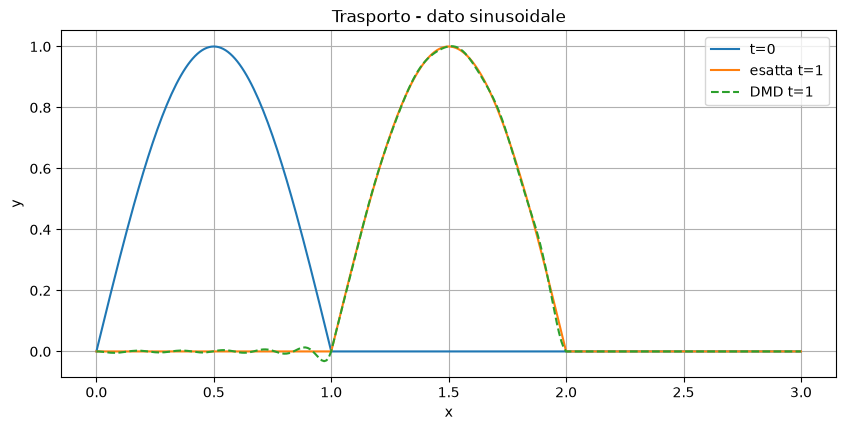

In [80]:
plt.figure(figsize=(10, 4.5))
plt.plot(x_tr, Y_tr_sine[:, 0], label="t=0")
plt.plot(x_tr, Y_tr_sine[:, -1], label="esatta t=1")
plt.plot(x_tr, Y_tr_sine_dmd[:, -1], "--", label="DMD t=1")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trasporto - dato sinusoidale")
plt.grid(True)
plt.legend()
plt.show()

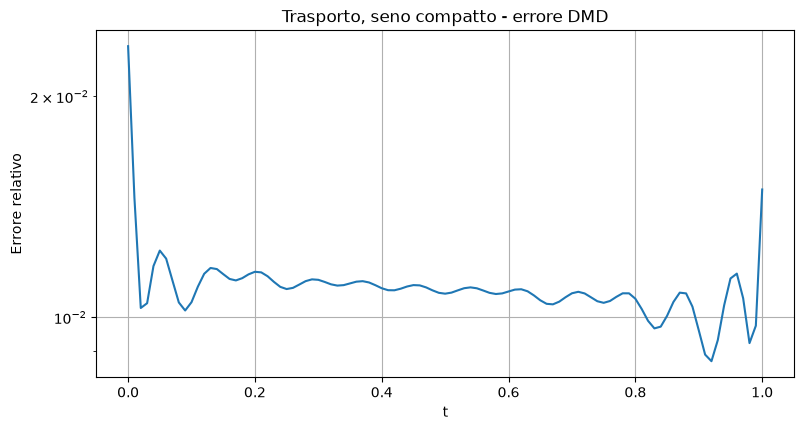

In [81]:
plot_error_curve(t_tr, err_tr_sine, "Trasporto, seno compatto - errore DMD")

In [82]:
# Trasporto con dato a blocco rettangolare

Y_tr_box = transport_snapshots(transport_y0_sign_box, x_tr, t_tr, c=1.0)
model_tr_box = dmd_fit(Y_tr_box, dt=dt_tr, energy=0.9999, max_rank=40)
Y_tr_box_dmd = dmd_reconstruct(model_tr_box, t_tr)
err_tr_box = relative_snapshot_error(Y_tr_box, Y_tr_box_dmd)

print("Rango DMD:", model_tr_box["rank"])
print("Errore Frobenius relativo:", relative_frobenius_error(Y_tr_box, Y_tr_box_dmd))

Rango DMD: 40
Errore Frobenius relativo: 0.17757422799247144


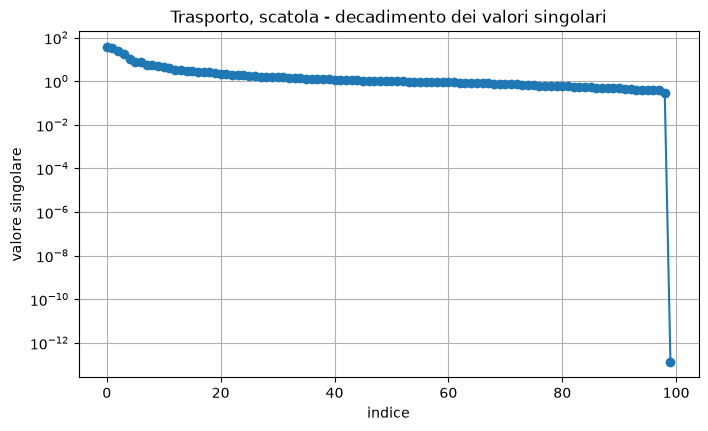

In [83]:
plt.figure(figsize=(8, 4.5))
plt.semilogy(model_tr_box["all_singular_values"], "o-")
plt.xlabel("indice")
plt.ylabel("valore singolare")
plt.title("Trasporto, scatola - decadimento dei valori singolari")
plt.grid(True)
plt.show()

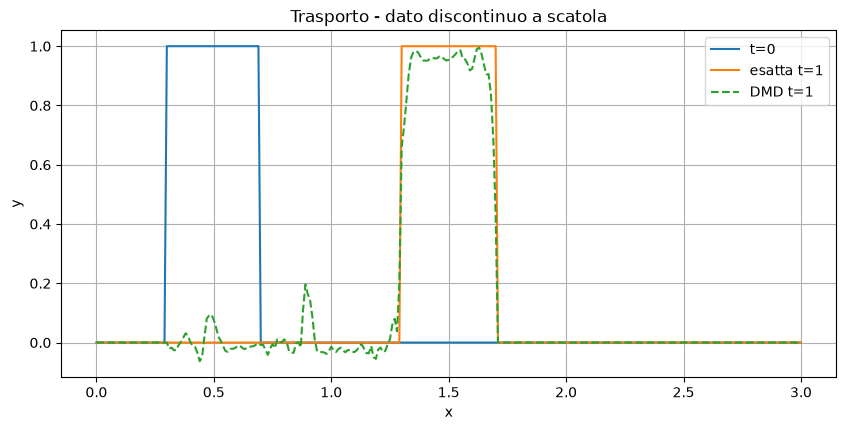

In [84]:
plt.figure(figsize=(10, 4.5))
plt.plot(x_tr, Y_tr_box[:, 0], label="t=0")
plt.plot(x_tr, Y_tr_box[:, -1], label="esatta t=1")
plt.plot(x_tr, Y_tr_box_dmd[:, -1], "--", label="DMD t=1")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trasporto - dato discontinuo a scatola")
plt.grid(True)
plt.legend()
plt.show()

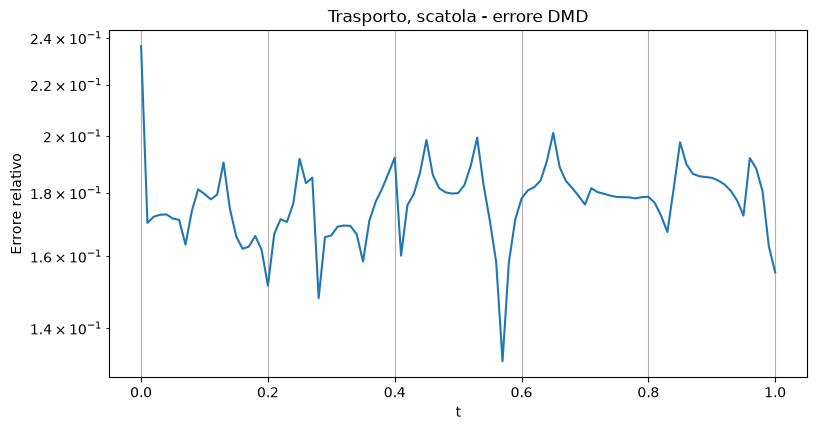

In [85]:
plot_error_curve(t_tr, err_tr_box, "Trasporto, scatola - errore DMD")

### Equazione di Allen-Cahn

In [86]:
def allen_cahn_2d_backward_euler_newton(
    alpha=0.1,
    mu=11.0,
    T=2.0,
    N=25,
    dt=0.01,
    random_initial=False,
    seed=1,
    newton_tol=1e-10,
    newton_maxit=20,
):
    #Allen-Cahn 2D con Backward Euler e Newton.
    #Equazione seguita dalla scheda:
    #    y_t = alpha*Delta(y) - mu*y + mu*y^3.
    #Le incognite sono solo sui nodi interni; il bordo è zero automaticamente.

    x = np.linspace(0.0, 1.0, N)
    h = x[1] - x[0]
    xi = x[1:-1]
    X1, X2 = np.meshgrid(xi, xi, indexing="ij")

    n = N - 2
    d = n*n
    L = laplacian_2d(n, h)
    I = eye(d, format="csc")

    if random_initial:
        # La condizione al contorno resta zero perché randomizziamo solo i nodi interni.
        rng = np.random.default_rng(seed)
        u = rng.uniform(-1.0, 1.0, size=d)
    else:
        u = (0.1 * np.sin(np.pi*X1) * np.sin(np.pi*X2)).ravel()

    nsteps = int(round(T / dt))
    snapshots = [u.copy()]
    times = [0.0]
    newton_iterations = []

    # Parte costante del Jacobiano di Newton.
    J_constant = I - dt*alpha*L + dt*mu*I

    for k in range(nsteps):
        u_old = u.copy()

        # Inizializzazione di Newton con il valore al tempo precedente
        z = u_old.copy()

        for it in range(newton_maxit):
            # F(z) = z - u_old - dt*f(z)
            F = z - u_old - dt*(alpha*(L @ z) - mu*z + mu*z**3)

            # J_F(z) = I - dt*J_f(z)
            J = J_constant - dt*mu*diags(3.0*z**2, offsets=0, format="csc")

            # Non formiamo mai J^{-1}: risolviamo J*delta = F.
            delta = spsolve(J, F)
            z = z - delta

            if np.linalg.norm(delta) <= newton_tol * (1.0 + np.linalg.norm(z)):
                break
        else:
            raise RuntimeError(f"Newton non converge al passo {k}.")

        newton_iterations.append(it + 1)
        u = z
        snapshots.append(u.copy())
        times.append((k + 1) * dt)

    return x, np.asarray(times), np.column_stack(snapshots), np.asarray(newton_iterations)

In [87]:
#dato iniziale sinusoidale
 
x_ac, t_ac, Y_ac, newton_it_ac = allen_cahn_2d_backward_euler_newton(
    alpha=0.1,
    mu=11.0,
    T=2.0,
    N=25,
    dt=0.01,
    random_initial=False,
)

model_ac = dmd_fit(Y_ac, dt=0.01, energy=0.9999, max_rank=40)
Y_ac_dmd = dmd_reconstruct(model_ac, t_ac)
err_ac = relative_snapshot_error(Y_ac, Y_ac_dmd)

print("Rango DMD:", model_ac["rank"])
print("Errore Frobenius relativo:", relative_frobenius_error(Y_ac, Y_ac_dmd))
print("Numero massimo di iterazioni Newton per passo:", newton_it_ac.max())

Rango DMD: 1
Errore Frobenius relativo: 0.000581562507796457
Numero massimo di iterazioni Newton per passo: 3


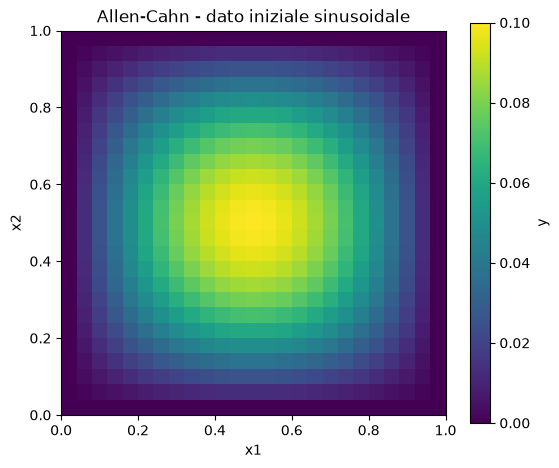

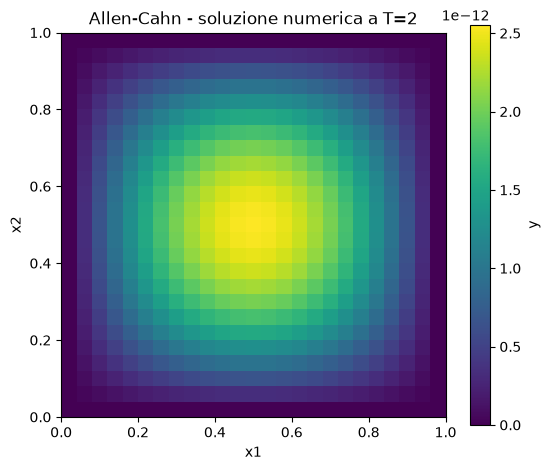

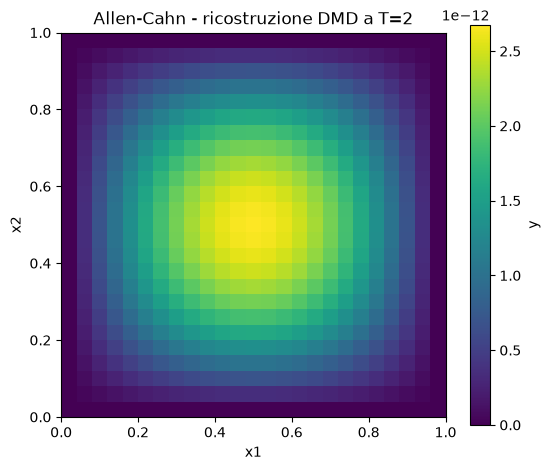

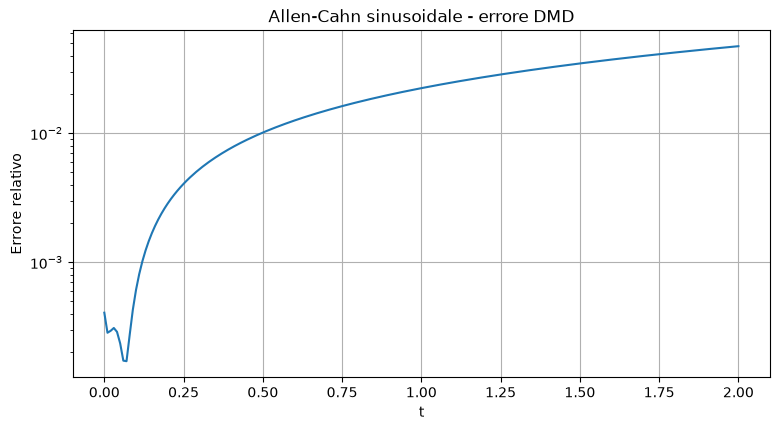

In [88]:
plot_field_2d(Y_ac[:, 0], x_ac, "Allen-Cahn - dato iniziale sinusoidale")
plot_field_2d(Y_ac[:, -1], x_ac, "Allen-Cahn - soluzione numerica a T=2")
plot_field_2d(Y_ac_dmd[:, -1], x_ac, "Allen-Cahn - ricostruzione DMD a T=2")
plot_error_curve(t_ac, err_ac, "Allen-Cahn sinusoidale - errore DMD")

In [89]:
#### Allen-Cahn - dato iniziale random in [-1,1]
 
x_ac_r, t_ac_r, Y_ac_r, newton_it_ac_r = allen_cahn_2d_backward_euler_newton(
    alpha=0.1,
    mu=11.0,
    T=2.0,
    N=25,
    dt=0.01,
    random_initial=True,
    seed=1,
)

random_rank_results = []
random_models = {}

for r in [1, 2, 4, 8]:
    m = dmd_fit(Y_ac_r, dt=0.01, rank=r)
    Yhat = dmd_reconstruct(m, t_ac_r)
    random_models[r] = (m, Yhat)
    random_rank_results.append({
        "rango": r,
        "errore_F_rel": relative_frobenius_error(Y_ac_r, Yhat),
    })

display(pd.DataFrame(random_rank_results))

,rango,errore_F_rel
0,1,0.482521
1,2,0.238977
2,4,0.065248
3,8,0.004766


In [90]:
# Per il riepilogo scegliamo automaticamente il rango con 99.99% di energia.
model_ac_r = dmd_fit(Y_ac_r, dt=0.01, energy=0.9999, max_rank=40)
Y_ac_r_dmd = dmd_reconstruct(model_ac_r, t_ac_r)

print("Rango automatico:", model_ac_r["rank"])
print("Errore Frobenius relativo:", relative_frobenius_error(Y_ac_r, Y_ac_r_dmd))

Rango automatico: 4
Errore Frobenius relativo: 0.06524781611672262


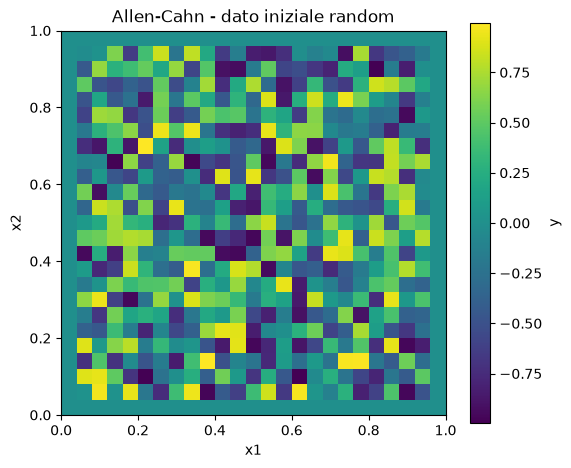

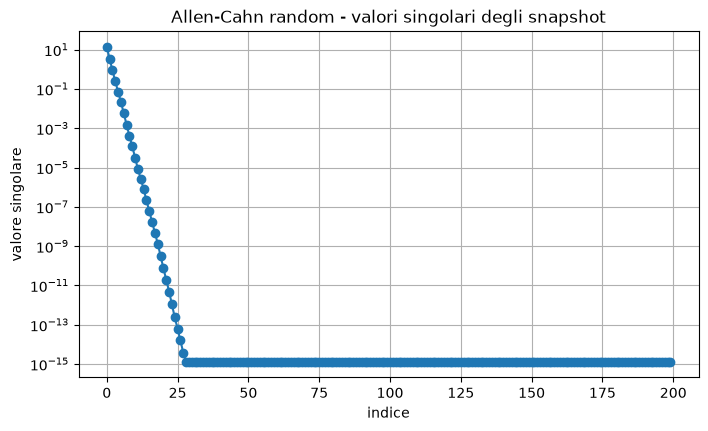

In [91]:
plot_field_2d(Y_ac_r[:, 0], x_ac_r, "Allen-Cahn - dato iniziale random")

plt.figure(figsize=(8, 4.5))
plt.semilogy(model_ac_r["all_singular_values"], "o-")
plt.xlabel("indice")
plt.ylabel("valore singolare")
plt.title("Allen-Cahn random - valori singolari degli snapshot")
plt.grid(True)
plt.show()

# Operator Inference

In [92]:
def first_derivative_centered_1d(n, h):

    #Matrice D per la derivata prima centrata sui nodi interni:
    #    u_x(x_i) ~= (u_{i+1} - u_{i-1})/(2h).
    #I contributi di bordo mancanti sono zero perché le condizioni di Dirichlet sono omogenee.

    off = np.ones(n - 1)
    return diags([-off, off], offsets=[-1, 1], shape=(n, n), format="csc") / (2.0*h)


def burgers_1d_forward_euler(alpha=0.01, T=1.0, dx=0.01, dt=1e-4, snapshot_stride=10):

    #Simula Burgers viscosa con Forward Euler.
    #Il passo interno è esattamente dt=1e-4 come richiesto dalla scheda.
    #salvo uno snapshot ogni `snapshot_stride` passi.

    x = np.arange(0.0, 2.0 + 0.5*dx, dx)
    xi = x[1:-1]
    n = len(xi)

    D1 = first_derivative_centered_1d(n, dx)
    D2 = laplacian_1d(n, dx)

    # y0(x) = sin(pi x) su [0,1], zero altrove.
    u = np.where(xi <= 1.0, np.sin(np.pi*xi), 0.0)

    nsteps = int(round(T / dt))
    snapshots = [u.copy()]
    times = [0.0]

    for k in range(1, nsteps + 1):
        # Semidiscretizzazione:
        #   u_t = alpha D2 u - u o (D1 u)
        rhs = alpha*(D2 @ u) - u*(D1 @ u)

        # Forward Euler:
        #   u^{n+1} = u^n + dt * rhs(u^n)
        u = u + dt*rhs

        if k % snapshot_stride == 0:
            snapshots.append(u.copy())
            times.append(k*dt)

    return x, np.asarray(times), np.column_stack(snapshots), D1, D2

In [93]:
alpha_burgers = 0.01   # scelta esplicita perché la scheda non fornisce il valore

x_b, t_b, Y_b, D1_b, D2_b = burgers_1d_forward_euler(
    alpha=alpha_burgers,
    T=1.0,
    dx=0.01,
    dt=1e-4,
    snapshot_stride=10,
)

print("Shape matrice snapshot Burgers:", Y_b.shape)
print("Passo temporale del solutore full-order: 1e-4")
print("Passo tra snapshot salvati:", t_b[1]-t_b[0])

Shape matrice snapshot Burgers: (199, 1001)
Passo temporale del solutore full-order: 1e-4
Passo tra snapshot salvati: 0.001


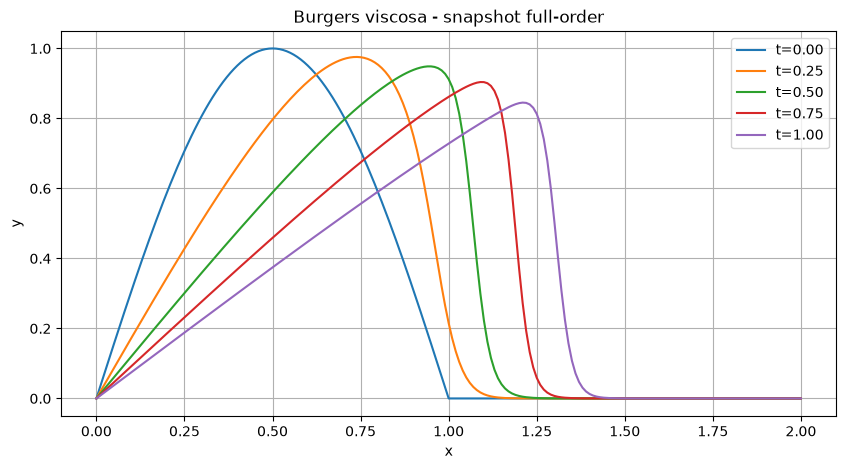

In [94]:
# Visualizziamo alcuni profili del modello full-order.
indices = [0, 250, 500, 750, 1000]

plt.figure(figsize=(10, 5))
for idx in indices:
    # Inseriamo i bordi nulli per il grafico.
    u_full = np.zeros_like(x_b)
    u_full[1:-1] = Y_b[:, idx]
    plt.plot(x_b, u_full, label=f"t={t_b[idx]:.2f}")

plt.xlabel("x")
plt.ylabel("y")
plt.title("Burgers viscosa - snapshot full-order")
plt.grid(True)
plt.legend()
plt.show()

In [95]:
def quadratic_kronecker_snapshots(Z):
    #Costruisce [z_j ⊗ z_j] per tutti gli snapshot.

    r, m = Z.shape
    return np.einsum("im,jm->ijm", Z, Z).reshape(r*r, m)


def operator_inference_quadratic(Z, dZ, lambda_A=1e-10, lambda_H=1e-8):

    #Impara A_r e H_r dalla regressione quadratica regolarizzata.
    #Modello:
    #    dZ/dt = A_r Z + H_r (Z ⊗ Z)
    #Risolve il problema ai minimi quadrati regolarizzato tramite sistema aumentato.
    r, m = Z.shape

    # Q[:,j] = z_j ⊗ z_j.
    Q = quadratic_kronecker_snapshots(Z)

    # Matrice D della teoria: ogni riga contiene [z_j^T, (z_j⊗z_j)^T].
    D = np.hstack([Z.T, Q.T])

    # Incognita O = [A_r H_r], quindi O ha r righe e r+r^2 colonne.
    p = r + r*r

    # Regolarizzazione Tikhonov separata su parte lineare e quadratica.
    # L = blockdiag(sqrt(lambda_A) I_r, sqrt(lambda_H) I_{r^2}).
    L = np.diag(np.r_[
        np.full(r, np.sqrt(lambda_A)),
        np.full(r*r, np.sqrt(lambda_H)),
    ])

    # Problema aumentato equivalente:
    # min || [D; L] O^T - [dZ^T; 0] ||_F.
    D_aug = np.vstack([D, L])
    R_aug = np.vstack([dZ.T, np.zeros((p, r))])

    # coeff ha shape (p, r) e rappresenta O^T.
    coeff, *_ = np.linalg.lstsq(D_aug, R_aug, rcond=None)
    O = coeff.T

    A_r = O[:, :r]
    H_r = O[:, r:]

    # Residuo non regolarizzato sui dati, utile come diagnostica.
    rel_regression_residual = np.linalg.norm(D @ coeff - dZ.T, "fro") / np.linalg.norm(dZ.T, "fro")

    return A_r, H_r, {
        "D": D,
        "O": O,
        "relative_regression_residual": rel_regression_residual,
        "condition_number_D": np.linalg.cond(D),
    }

In [96]:
#POD per ridurre la dimensione del sistema full-order di Burgers.

U_b, s_b, Vh_b = np.linalg.svd(Y_b, full_matrices=False)

r_b = 10
Psi_b = U_b[:, :r_b]
Z_b = Psi_b.T @ Y_b

captured_energy_b = np.sum(s_b[:r_b]**2) / np.sum(s_b**2)

print(f"Rango POD scelto: {r_b}")
print(f"Energia snapshot catturata: {100*captured_energy_b:.6f}%")
print("Dimensione full-order:", Y_b.shape[0])
print("Dimensione ridotta:", r_b)

Rango POD scelto: 10
Energia snapshot catturata: 99.998791%
Dimensione full-order: 199
Dimensione ridotta: 10


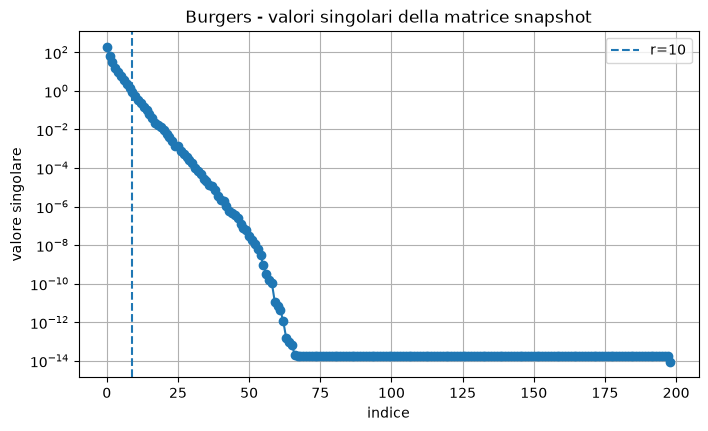

In [97]:
plt.figure(figsize=(8, 4.5))
plt.semilogy(s_b, "o-")
plt.axvline(r_b - 1, linestyle="--", label=f"r={r_b}")
plt.xlabel("indice")
plt.ylabel("valore singolare")
plt.title("Burgers - valori singolari della matrice snapshot")
plt.grid(True)
plt.legend()
plt.show()

In [98]:
# Valutazione del RHS full-order su tutti gli snapshot contemporaneamente.
dY_b = alpha_burgers*(D2_b @ Y_b) - Y_b*(D1_b @ Y_b)

# Proiezione POD delle derivate.
dZ_b = Psi_b.T @ dY_b

# Alternativa completamente data-driven, se non conoscessimo il RHS:
# dZ_b = np.gradient(Z_b, t_b, axis=1, edge_order=2)

print("Shape Z  :", Z_b.shape)
print("Shape dZ :", dZ_b.shape)

Shape Z  : (10, 1001)
Shape dZ : (10, 1001)


In [99]:
A_r_b, H_r_b, opinf_info = operator_inference_quadratic(
    Z_b,
    dZ_b,
    lambda_A=1e-10,
    lambda_H=1e-8,
)

print("Shape A_r:", A_r_b.shape)
print("Shape H_r:", H_r_b.shape)
print("Numero di feature r+r^2:", r_b + r_b**2)
print("Condizionamento della matrice D:", opinf_info["condition_number_D"])
print("Residuo relativo della regressione:", opinf_info["relative_regression_residual"])

Shape A_r: (10, 10)
Shape H_r: (10, 100)
Numero di feature r+r^2: 110
Condizionamento della matrice D: 5.792805236532809e+41
Residuo relativo della regressione: 6.8107619313915725e-06


In [100]:
def opinf_rhs(t, z, A_r, H_r):
    """RHS del modello quadratico ridotto imparato."""
    return A_r @ z + H_r @ np.kron(z, z)

sol_b_red = solve_ivp(
    lambda t, z: opinf_rhs(t, z, A_r_b, H_r_b),
    (t_b[0], t_b[-1]),
    Z_b[:, 0],
    t_eval=t_b,
    method="BDF",
    rtol=1e-7,
    atol=1e-9,
)

if not sol_b_red.success:
    raise RuntimeError(sol_b_red.message)

Z_b_opinf = sol_b_red.y
Y_b_opinf = Psi_b @ Z_b_opinf

err_b_opinf = relative_snapshot_error(Y_b, Y_b_opinf)
err_b_opinf_F = relative_frobenius_error(Y_b, Y_b_opinf)

print("Errore Frobenius relativo OpInf:", err_b_opinf_F)
print("Errore relativo all'ultimo snapshot:", err_b_opinf[-1])

Errore Frobenius relativo OpInf: 0.0034968513768867207
Errore relativo all'ultimo snapshot: 0.011372222287446443


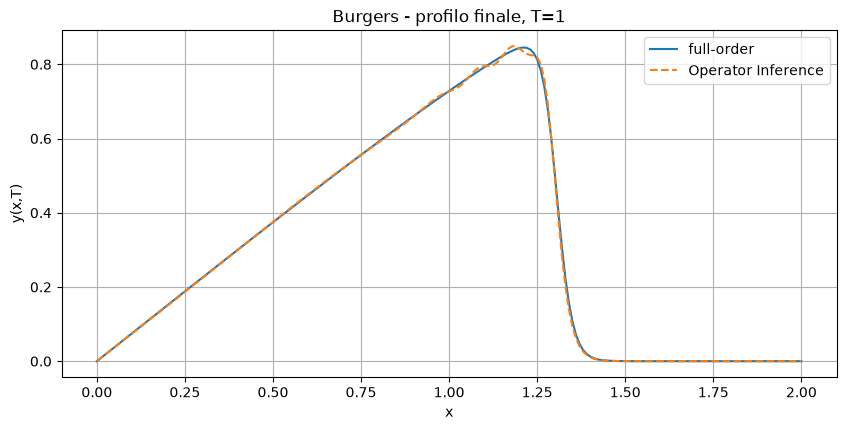

In [101]:
# Profilo finale: full-order vs Operator Inference.
u_full_T = np.zeros_like(x_b)
u_full_T[1:-1] = Y_b[:, -1]

u_opinf_T = np.zeros_like(x_b)
u_opinf_T[1:-1] = Y_b_opinf[:, -1]

plt.figure(figsize=(10, 4.5))
plt.plot(x_b, u_full_T, label="full-order")
plt.plot(x_b, u_opinf_T, "--", label="Operator Inference")
plt.xlabel("x")
plt.ylabel("y(x,T)")
plt.title("Burgers - profilo finale, T=1")
plt.grid(True)
plt.legend()
plt.show()

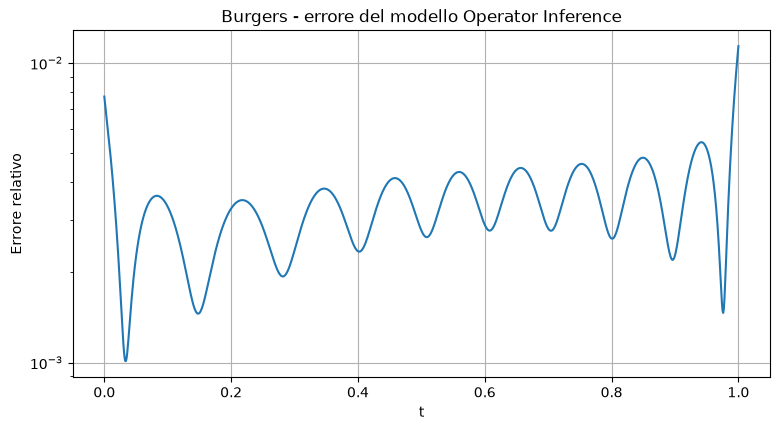

In [102]:
plot_error_curve(t_b, err_b_opinf, "Burgers - errore del modello Operator Inference")